# Parks in Melbourne - Exploratory Data Analysis

This notebook adds essential visual checks for the hypothesis **"Parks cool the city"** using the microclimate sensor dataset.

Primary outcomes in this EDA:
- `H1`: park vs street temperature gap (especially summer afternoons)
- `H2`: park vs street relative humidity difference
- `H3`: heatwave amplification of the park-street temperature gap
- `H4`: daytime vs nighttime asymmetry in cooling
- `H5/H6`: optional canopy/species dose-response plots (enabled when context file is available)


## 1. Setup and Imports

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_colwidth = 100

CSV_PATH = Path('microclimate-sensors-data.csv')
assert CSV_PATH.exists(), f"Missing data file: {CSV_PATH}"

from scipy.interpolate import griddata

## 2. Load and Clean Microclimate Data

In [21]:
df = pd.read_csv(CSV_PATH)

# Parse timezone-aware timestamps and convert to Melbourne local time.
df['Time'] = pd.to_datetime(df['Time'], utc=True).dt.tz_convert('Australia/Melbourne')

# Split "lat, lon" into numeric columns for mapping.
latlon = df['LatLong'].str.split(',', expand=True)
df['Latitude'] = pd.to_numeric(latlon[0], errors='coerce')
df['Longitude'] = pd.to_numeric(latlon[1], errors='coerce')

# Keep only rows with key fields needed for H1-H4.
working = df.dropna(subset=['SensorLocation', 'AirTemperature', 'RelativeHumidity']).copy()

# Site class mapping for hypothesis testing.
def classify_site(sensor_location: str) -> str:
    s = sensor_location.lower()

    if any(k in s for k in ['rooftop', 'skyfarm', 'ch1']):
        return 'rooftop'

    if any(k in s for k in ['birrarung', 'enterprize', 'royal park', 'batman park']):
        return 'park'

    if any(k in s for k in ['tram stop', 'swanston', 'treasury place']):
        return 'street'

    return 'unknown'

working['LandType'] = working['SensorLocation'].map(classify_site)
working = working[working['LandType'] != 'unknown'].copy()

# Short labels for cleaner chart annotations.
SHORT_NAME_MAP = {
    'Birrarung Marr Park - Pole 1131': 'Birrarung Marr',
    'Enterprize Park - Pole ID: COM1667': 'Enterprize Park',
    'Royal Park Asset ID: COM2707': 'Royal Park',
    'Batman Park': 'Batman Park',
    'Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station': 'Swanston Stop 13',
    'Tram Stop 7B - Melbourne Tennis Centre Precinct - Rod Laver Arena': 'Tram Stop 7B',
    'Tram Stop 7C - Melbourne Tennis Centre Precinct - Rod Laver Arena': 'Tram Stop 7C',
    '1 Treasury Place': '1 Treasury Pl',
    '101 Collins St L11 Rooftop': '101 Collins L11',
    'CH1 rooftop': 'CH1 rooftop',
    "SkyFarm (Jeff's Shed). Rooftop - Melbourne Conference & Exhibition Centre (MCEC)": 'MCEC SkyFarm',
}

working['SiteShortName'] = working['SensorLocation'].map(SHORT_NAME_MAP).fillna(working['SensorLocation'])

print(f"Rows after cleaning: {len(working):,}")
print(f"Time range: {working['Time'].min()} to {working['Time'].max()}")
print('\nLandType coverage:')
print(working['LandType'].value_counts())


Rows after cleaning: 585,161
Time range: 2024-05-30 16:38:20+10:00 to 2026-03-16 10:52:48+11:00

LandType coverage:
LandType
street     251605
rooftop    171363
park       162193
Name: count, dtype: int64


In [22]:
site_summary = (
    working.groupby(['SensorLocation', 'SiteShortName', 'LandType'], as_index=False)
    .agg(
        n_obs=('AirTemperature', 'size'),
        mean_temp_c=('AirTemperature', 'mean'),
        mean_rh_pct=('RelativeHumidity', 'mean'),
        latitude=('Latitude', 'median'),
        longitude=('Longitude', 'median'),
    )
    .sort_values(['LandType', 'SiteShortName'])
)

site_summary


,SensorLocation,SiteShortName,LandType,n_obs,mean_temp_c,mean_rh_pct,latitude,longitude
2,Batman Park,Batman Park,park,26126,18.632389,61.738023,-37.822183,144.956222
3,Birrarung Marr Park - Pole 1131,Birrarung Marr,park,61346,15.850352,70.240050,-37.818593,144.971640
5,Enterprize Park - Pole ID: COM1667,Enterprize Park,park,44033,17.279920,69.384101,-37.820408,144.959119
6,Royal Park Asset ID: COM2707,Royal Park,park,30688,14.777613,76.259945,-37.795617,144.951901
1,101 Collins St L11 Rooftop,101 Collins L11,rooftop,59401,16.533306,68.091147,-37.814604,144.970299
4,CH1 rooftop,CH1 rooftop,rooftop,58604,16.014752,69.296106,-37.814035,144.967280
7,SkyFarm (Jeff's Shed). Rooftop - Melbourne Conference & Exhibition Centre (MCEC),MCEC SkyFarm,rooftop,53358,17.010385,62.759221,-37.822331,144.952170
0,1 Treasury Place,1 Treasury Pl,street,75540,15.529117,63.535184,-37.812888,144.975086
8,Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station,Swanston Stop 13,street,58229,16.361701,63.228278,-37.818452,144.967847
9,Tram Stop 7B - Melbourne Tennis Centre Precinct - Rod Laver Arena,Tram Stop 7B,street,58831,16.289533,63.910799,-37.819499,144.978721


## 3. Sensor Geography and Class Split

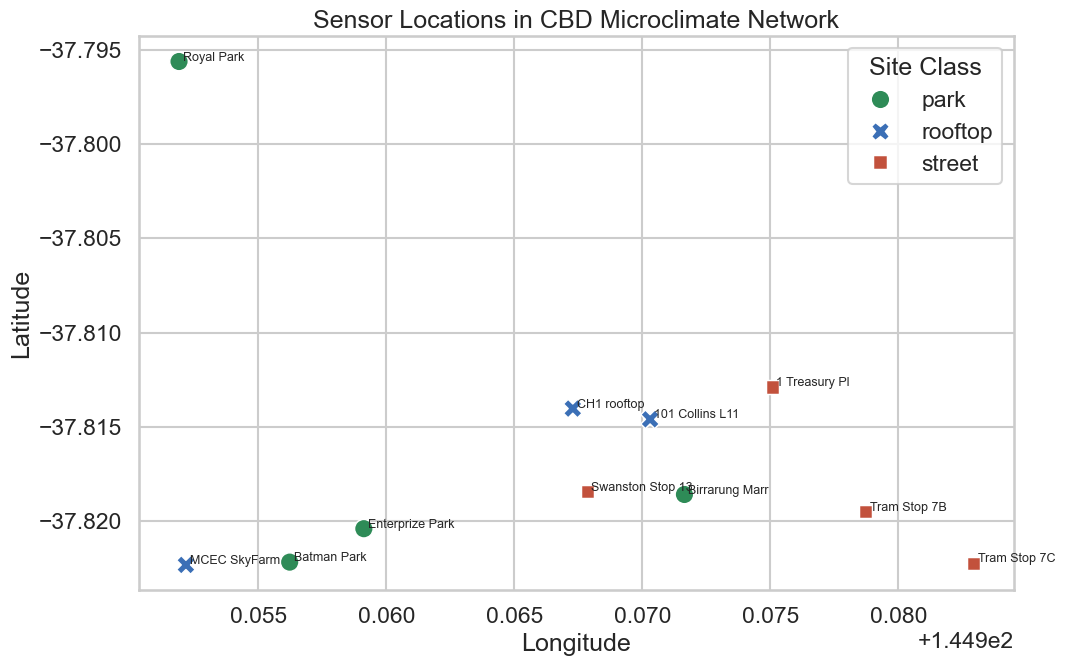

In [23]:
plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=site_summary,
    x='longitude',
    y='latitude',
    hue='LandType',
    style='LandType',
    s=180,
    palette={'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'},
)

for _, row in site_summary.iterrows():
    ax.text(row['longitude'] + 0.00015, row['latitude'] + 0.00005, row['SiteShortName'], fontsize=9)

ax.set_title('Sensor Locations in CBD Microclimate Network')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.legend(title='Site Class', loc='best')
plt.tight_layout()
plt.show()


## 3B. Spatial City Heatmap (Warmer vs Colder Areas)

This map uses sensor coordinates to estimate a continuous **street-level** temperature surface.
- Focus window: **summer afternoons (Dec-Feb, 13:00-17:00)**
- Rooftop sensors are excluded to emphasize what people feel at ground level.


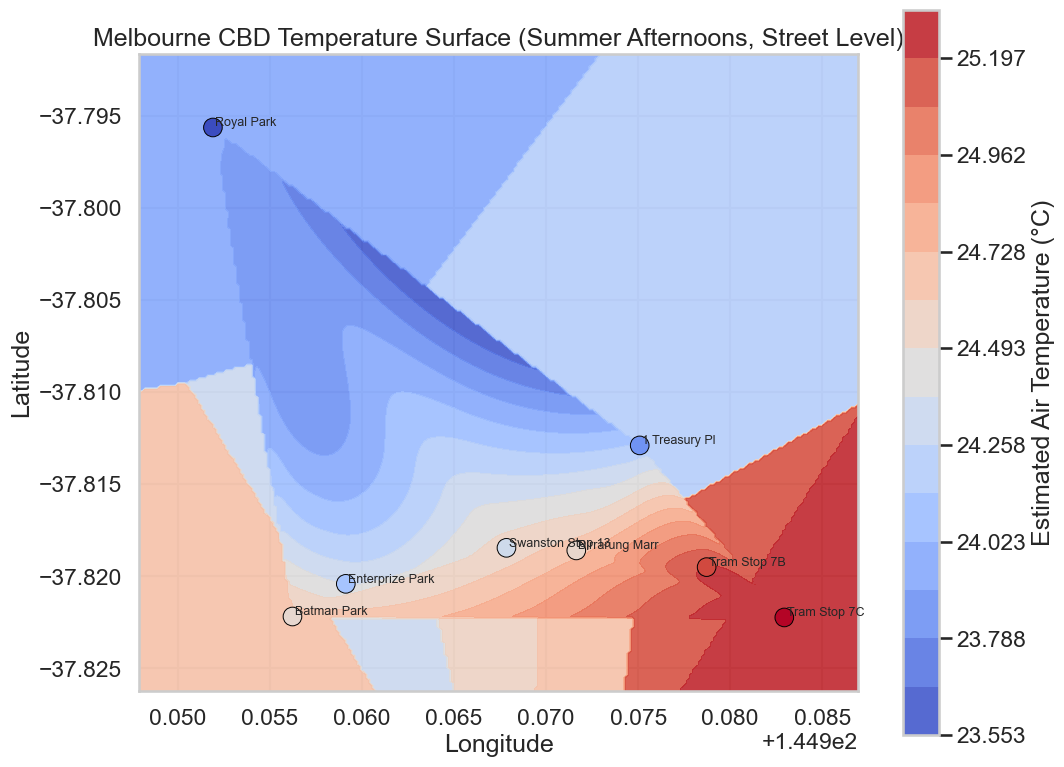

,SiteShortName,LandType,mean_temp_c,n_obs
4,Royal Park,park,23.928669,1765
0,1 Treasury Pl,street,24.161762,5063
3,Enterprize Park,park,24.373555,3131
5,Swanston Stop 13,street,24.546749,3091
1,Batman Park,park,24.671492,1796
2,Birrarung Marr,park,24.682710,3609
6,Tram Stop 7B,street,25.196738,3127
7,Tram Stop 7C,street,25.314860,3136


In [24]:
map_subset = working[
    working['LandType'].isin(['park', 'street'])
    & working['Time'].dt.month.isin([12, 1, 2])
    & working['Time'].dt.hour.between(13, 17)
].copy()

sensor_map_temp = (
    map_subset.groupby(['SensorLocation', 'SiteShortName', 'LandType'], as_index=False)
    .agg(
        mean_temp_c=('AirTemperature', 'mean'),
        latitude=('Latitude', 'median'),
        longitude=('Longitude', 'median'),
        n_obs=('AirTemperature', 'size'),
    )
    .dropna(subset=['latitude', 'longitude', 'mean_temp_c'])
)

x = sensor_map_temp['longitude'].to_numpy()
y = sensor_map_temp['latitude'].to_numpy()
z = sensor_map_temp['mean_temp_c'].to_numpy()

pad = 0.004
xi = np.linspace(x.min() - pad, x.max() + pad, 240)
yi = np.linspace(y.min() - pad, y.max() + pad, 240)
XI, YI = np.meshgrid(xi, yi)

# Interpolate sparse sensor observations to a smooth surface.
ZI = griddata((x, y), z, (XI, YI), method='cubic')
if np.isnan(ZI).all():
    ZI = griddata((x, y), z, (XI, YI), method='linear')

# Fill edge NaNs so the heatmap remains readable outside convex hull boundaries.
ZI_nearest = griddata((x, y), z, (XI, YI), method='nearest')
ZI = np.where(np.isnan(ZI), ZI_nearest, ZI)

fig, ax = plt.subplots(figsize=(11, 9))
levels = np.linspace(np.nanmin(ZI), np.nanmax(ZI), 16)
heat = ax.contourf(XI, YI, ZI, levels=levels, cmap='coolwarm', alpha=0.9)

pts = ax.scatter(
    sensor_map_temp['longitude'],
    sensor_map_temp['latitude'],
    c=sensor_map_temp['mean_temp_c'],
    cmap='coolwarm',
    s=180,
    edgecolor='black',
    linewidth=0.7,
    zorder=3,
)

for _, row in sensor_map_temp.iterrows():
    ax.text(row['longitude'] + 0.00012, row['latitude'] + 0.00008, row['SiteShortName'], fontsize=9)

cbar = fig.colorbar(heat, ax=ax, shrink=0.88)
cbar.set_label('Estimated Air Temperature (°C)')

ax.set_title('Melbourne CBD Temperature Surface (Summer Afternoons, Street Level)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

sensor_map_temp[['SiteShortName', 'LandType', 'mean_temp_c', 'n_obs']].sort_values('mean_temp_c')


## 3C. Interactive Geographical Heatmap (Melbourne Basemap)

An interactive map of Melbourne CBD overlaying sensor mean air temperatures on an OpenStreetMap basemap.
- Heat intensity is weighted by **summer afternoon (Dec-Feb, 13:00-17:00)** mean temperature per sensor.
- Click a marker to see the site name, class, mean temperature, and number of observations.
- Rooftops are shown as markers but excluded from the heat layer to keep focus on street-level experience.


In [38]:
import folium
from folium.plugins import HeatMap
from IPython.display import IFrame

# Reuse summer-afternoon per-sensor aggregate computed earlier in section 3B.
ground_sites = sensor_map_temp.copy()

# Include rooftops as markers (not in heat layer) for spatial context.
rooftop_sites = (
    working[
        (working['LandType'] == 'rooftop')
        & working['Time'].dt.month.isin([12, 1, 2])
        & working['Time'].dt.hour.between(13, 17)
    ]
    .groupby(['SensorLocation', 'SiteShortName', 'LandType'], as_index=False)
    .agg(
        mean_temp_c=('AirTemperature', 'mean'),
        latitude=('Latitude', 'median'),
        longitude=('Longitude', 'median'),
        n_obs=('AirTemperature', 'size'),
    )
    .dropna(subset=['latitude', 'longitude', 'mean_temp_c'])
)

all_sites = pd.concat([ground_sites, rooftop_sites], ignore_index=True)

# Summer-afternoon mean wind speed per sensor, for popup context.
wind_by_site = (
    working[
        working['Time'].dt.month.isin([12, 1, 2])
        & working['Time'].dt.hour.between(13, 17)
    ]
    .groupby('SensorLocation', as_index=False)
    .agg(
        mean_wind_mps=('AverageWindSpeed', 'mean'),
        mean_gust_mps=('GustWindSpeed', 'mean'),
    )
)
all_sites = all_sites.merge(wind_by_site, on='SensorLocation', how='left')

center_lat = ground_sites['latitude'].mean()
center_lon = ground_sites['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='OpenStreetMap')

# Rank-based weights spread the 7 ground sites evenly across the full [0, 1]
# gradient — otherwise min-max compresses intermediate sites into the middle
# and washes out the warm/cold contrast.
n = len(ground_sites)
if n > 1:
    weights = (ground_sites['mean_temp_c'].rank(method='average') - 1) / (n - 1)
else:
    weights = pd.Series([0.5] * n, index=ground_sites.index)

heat_points = [
    [row['latitude'], row['longitude'], float(weight)]
    for (_, row), weight in zip(ground_sites.iterrows(), weights)
]

# Diverging palette with saturated poles and a pale-yellow midpoint —
# makes warm vs cold pockets read at a glance even through the basemap.
HeatMap(
    heat_points,
    radius=55,
    blur=30,
    min_opacity=0.55,
    max_zoom=17,
    gradient={
        0.0: '#2166AC',
        0.25: '#67A9CF',
        0.5: '#FFFFBF',
        0.75: '#F4A582',
        1.0: '#B2182B',
    },
).add_to(m)

class_color = {'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'}
marker_outline = '#1E5FA8'

# Citywide mean wind speed across all sites in the summer-afternoon window.
citywide_wind_mps = wind_by_site['mean_wind_mps'].mean()

for _, row in all_sites.iterrows():
    wind_val = row['mean_wind_mps']
    gust_val = row['mean_gust_mps']
    wind_str = f"{wind_val:.2f} m/s" if pd.notna(wind_val) else 'n/a'
    gust_str = f"{gust_val:.2f} m/s" if pd.notna(gust_val) else 'n/a'
    popup_html = (
        f"<b>{row['SiteShortName']}</b><br>"
        f"Class: {row['LandType']}<br>"
        f"Mean temp: {row['mean_temp_c']:.2f} °C<br>"
        f"Mean wind: {wind_str}<br>"
        f"Mean gust: {gust_str}<br>"
        f"Observations: {int(row['n_obs']):,}"
    )
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8,
        color=marker_outline,
        weight=2,
        fill=True,
        fill_color=class_color.get(row['LandType'], '#888'),
        fill_opacity=0.95,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=row['SiteShortName'],
    ).add_to(m)

# Temperature range at the ground sites — surfaced in the legend so the
# warm/cold gradient has a concrete scale instead of a relative one.
t_min = ground_sites['mean_temp_c'].min()
t_max = ground_sites['mean_temp_c'].max()

legend_html = f'''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; padding: 10px 14px; border: 1px solid #888;
            border-radius: 6px; font-size: 13px; box-shadow: 0 1px 4px rgba(0,0,0,0.2);
            color: black;">
  <b>Sensor class</b> <span style="color:#555;">(blue outline)</span><br>
  <span style="display:inline-block;width:12px;height:12px;background:#2E8B57;border:2px solid {marker_outline};border-radius:50%;margin-right:6px;"></span>Park<br>
  <span style="display:inline-block;width:12px;height:12px;background:#C2513C;border:2px solid {marker_outline};border-radius:50%;margin-right:6px;"></span>Street<br>
  <span style="display:inline-block;width:12px;height:12px;background:#3B6FB6;border:2px solid {marker_outline};border-radius:50%;margin-right:6px;"></span>Rooftop<br>
  <hr style="margin:6px 0;">
  <b>Heat layer</b>: summer afternoon mean temp (ground only)<br>
  <div style="margin-top:4px;height:10px;width:180px;border:1px solid #666;
              background:linear-gradient(to right,#2166AC,#67A9CF,#FFFFBF,#F4A582,#B2182B);"></div>
  <div style="display:flex;justify-content:space-between;width:180px;font-size:11px;color:#333;">
    <span>{t_min:.1f}°C</span><span>cool ↔ warm</span><span>{t_max:.1f}°C</span>
  </div>
  <hr style="margin:6px 0;">
  <b>Citywide mean wind</b>: {citywide_wind_mps:.2f} m/s<br>
  <span style="color:#555;">(summer afternoons, 13:00-17:00)</span>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save to standalone HTML and embed via IFrame — renders reliably in VSCode
# notebook viewer, where folium's default inline iframe can appear black.
map_html_path = 'melbourne_heatmap.html'
m.save(map_html_path)
print(f'Saved interactive map to {map_html_path} — also open it directly in a browser for a full-size view.')

IFrame(src=map_html_path, width='100%', height=600)

Saved interactive map to melbourne_heatmap.html — also open it directly in a browser for a full-size view.


## 4. Matched Hourly Aggregates (for park-street comparisons)

In [26]:
# Hourly mean by individual sensor location.
hourly_site = (
    working.set_index('Time')
    .groupby(['SensorLocation', 'SiteShortName', 'LandType'])[['AirTemperature', 'RelativeHumidity']]
    .resample('1h')
    .mean()
    .reset_index()
)

# Hourly mean by site class (park / street / rooftop).
hourly_class = (
    hourly_site.groupby(['Time', 'LandType'], as_index=False)[['AirTemperature', 'RelativeHumidity']]
    .mean()
)

# Wide format to compute class gaps at matched timestamps.
temp_wide = hourly_class.pivot(index='Time', columns='LandType', values='AirTemperature')
rh_wide = hourly_class.pivot(index='Time', columns='LandType', values='RelativeHumidity')

gap_df = pd.DataFrame(index=temp_wide.index)
gap_df['street_minus_park_temp_c'] = temp_wide.get('street') - temp_wide.get('park')
gap_df['park_minus_street_rh_pct'] = rh_wide.get('park') - rh_wide.get('street')
gap_df['hour'] = gap_df.index.hour
gap_df['month'] = gap_df.index.month
gap_df['date'] = gap_df.index.date

# Keep only rows where both park and street are available.
gap_df = gap_df.dropna(subset=['street_minus_park_temp_c', 'park_minus_street_rh_pct']).copy()

print(f"Matched hourly samples (park vs street): {len(gap_df):,}")
gap_df.head()


Matched hourly samples (park vs street): 14,892


,street_minus_park_temp_c,park_minus_street_rh_pct,hour,month,date
Time,,,,,
2024-05-30 16:00:00+10:00,0.800000,10.233334,16,5,2024-05-30
2024-05-30 17:00:00+10:00,1.058333,15.408334,17,5,2024-05-30
2024-05-30 18:00:00+10:00,1.111667,14.285000,18,5,2024-05-30
2024-05-30 19:00:00+10:00,1.029167,12.695834,19,5,2024-05-30
2024-05-30 20:00:00+10:00,1.097222,15.540277,20,5,2024-05-30


In [ ]:
# Overall average air temperature by site class.
avg_temp_by_landtype = (
    working[working['LandType'].isin(['park', 'street', 'rooftop'])]
    .groupby('LandType', as_index=False)['AirTemperature']
    .mean()
    .rename(columns={'AirTemperature': 'avg_temp_c'})
)

avg_temp_by_landtype['avg_temp_c'] = avg_temp_by_landtype['avg_temp_c'].round(2)
avg_temp_by_landtype.sort_values('LandType')

## 5. H1 - Mean Temperature Gap (Park vs Street)

In [ ]:
SUMMER_MONTHS = [11, 12, 1, 2, 3]

summer_hourly_class = hourly_class[hourly_class['Time'].dt.month.isin(SUMMER_MONTHS)].copy()

temp_profile = (
    summer_hourly_class.assign(hour=summer_hourly_class['Time'].dt.hour)
    .groupby(['LandType', 'hour'], as_index=False)['AirTemperature']
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=temp_profile,
    x='hour',
    y='AirTemperature',
    hue='LandType',
    marker='o',
    palette={'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'},
)
plt.axvspan(13, 17, color='gold', alpha=0.15, label='Summer afternoon focus')
plt.title('Diurnal Air Temperature by Site Class (Summer: Nov-Mar)')
plt.xlabel('Hour of day (AEST/AEDT local time)')
plt.ylabel('Mean Air Temperature (°C)')
plt.xlim(0, 23)
plt.legend(title='Site Class', loc='best')
plt.tight_layout()
plt.show()


/var/folders/qp/5zn1806d2q183t3j1x_pt5x80000gn/T/ipykernel_20989/3414566794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


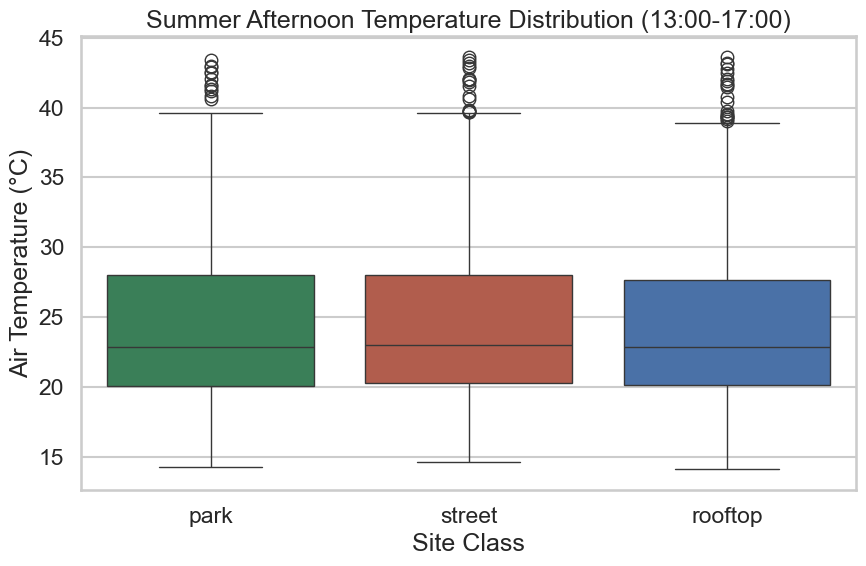

,mean_temp_c
LandType,
park,24.470667
rooftop,24.459113
street,24.749767
street_minus_park_gap_c,0.279099


In [28]:
summer_afternoon = hourly_class[
    hourly_class['Time'].dt.month.isin([12, 1, 2])
    & hourly_class['Time'].dt.hour.between(13, 17)
    & hourly_class['LandType'].isin(['park', 'street', 'rooftop'])
].copy()

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=summer_afternoon,
    x='LandType',
    y='AirTemperature',
    order=['park', 'street', 'rooftop'],
    palette={'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'},
)
plt.title('Summer Afternoon Temperature Distribution (13:00-17:00)')
plt.xlabel('Site Class')
plt.ylabel('Air Temperature (°C)')
plt.tight_layout()
plt.show()

h1_table = (
    summer_afternoon.groupby('LandType')['AirTemperature']
    .mean()
    .rename('mean_temp_c')
    .to_frame()
)
h1_table.loc['street_minus_park_gap_c', 'mean_temp_c'] = (
    h1_table.loc['street', 'mean_temp_c'] - h1_table.loc['park', 'mean_temp_c']
)
h1_table


## 6. H2 - Humidity Inversion (Park > Street)

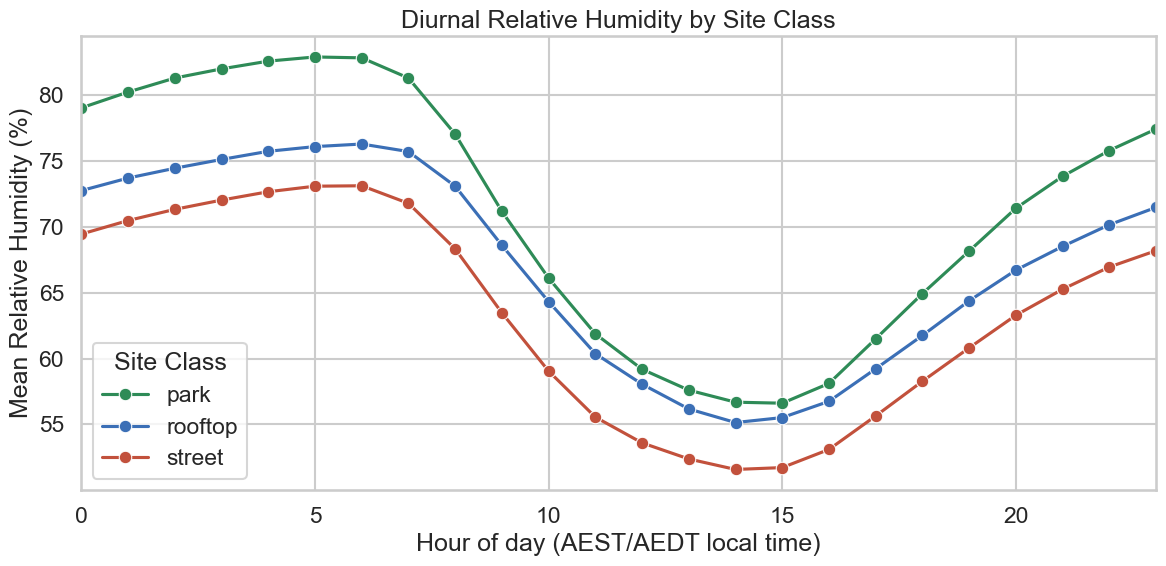

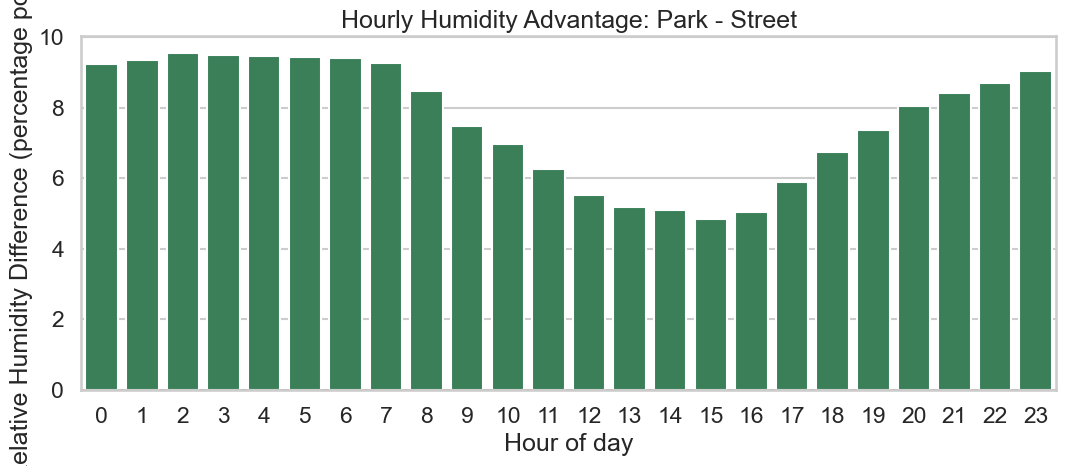

In [29]:
rh_profile = (
    hourly_class.assign(hour=hourly_class['Time'].dt.hour)
    .groupby(['LandType', 'hour'], as_index=False)['RelativeHumidity']
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=rh_profile,
    x='hour',
    y='RelativeHumidity',
    hue='LandType',
    marker='o',
    palette={'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'},
)
plt.title('Diurnal Relative Humidity by Site Class')
plt.xlabel('Hour of day (AEST/AEDT local time)')
plt.ylabel('Mean Relative Humidity (%)')
plt.xlim(0, 23)
plt.legend(title='Site Class', loc='best')
plt.tight_layout()
plt.show()

humidity_gap_profile = (
    gap_df.groupby('hour', as_index=False)['park_minus_street_rh_pct']
    .mean()
    .rename(columns={'park_minus_street_rh_pct': 'park_minus_street_rh'})
)

plt.figure(figsize=(11, 5))
sns.barplot(data=humidity_gap_profile, x='hour', y='park_minus_street_rh', color='#2E8B57')
plt.axhline(0, color='black', linewidth=1)
plt.title('Hourly Humidity Advantage: Park - Street')
plt.xlabel('Hour of day')
plt.ylabel('Relative Humidity Difference (percentage points)')
plt.tight_layout()
plt.show()


## 6B. Heatmaps - When Is the Cooling Signal Strongest?

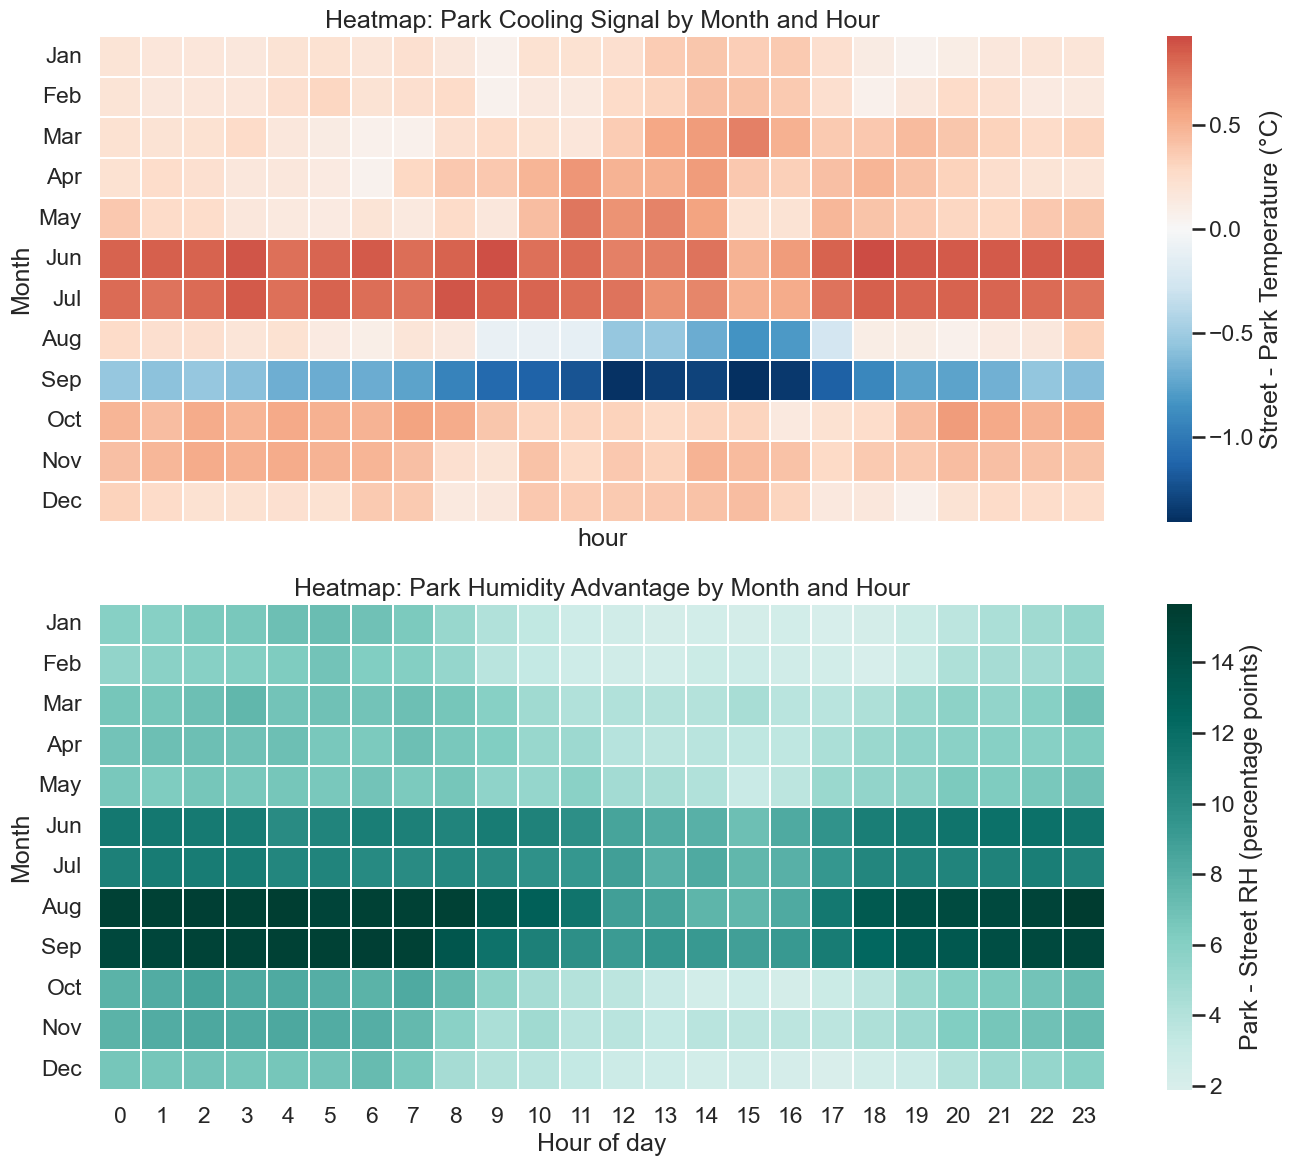

In [30]:
heat = gap_df.copy()
heat['month'] = pd.to_datetime(heat['date']).dt.month
heat['hour'] = heat['hour'].astype(int)

temp_heat = (
    heat.groupby(['month', 'hour'])['street_minus_park_temp_c']
    .mean()
    .unstack('hour')
    .reindex(range(1, 13))
)

rh_heat = (
    heat.groupby(['month', 'hour'])['park_minus_street_rh_pct']
    .mean()
    .unstack('hour')
    .reindex(range(1, 13))
)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
temp_heat.index = month_labels
rh_heat.index = month_labels

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.heatmap(
    temp_heat,
    cmap='RdBu_r',
    center=0,
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Street - Park Temperature (°C)'},
    ax=axes[0],
)
axes[0].set_title('Heatmap: Park Cooling Signal by Month and Hour')
axes[0].set_ylabel('Month')

sns.heatmap(
    rh_heat,
    cmap='BrBG',
    center=0,
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Park - Street RH (percentage points)'},
    ax=axes[1],
)
axes[1].set_title('Heatmap: Park Humidity Advantage by Month and Hour')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Month')

plt.tight_layout()
plt.show()


## 7. H3 - Heatwave Amplification of Cooling Gap

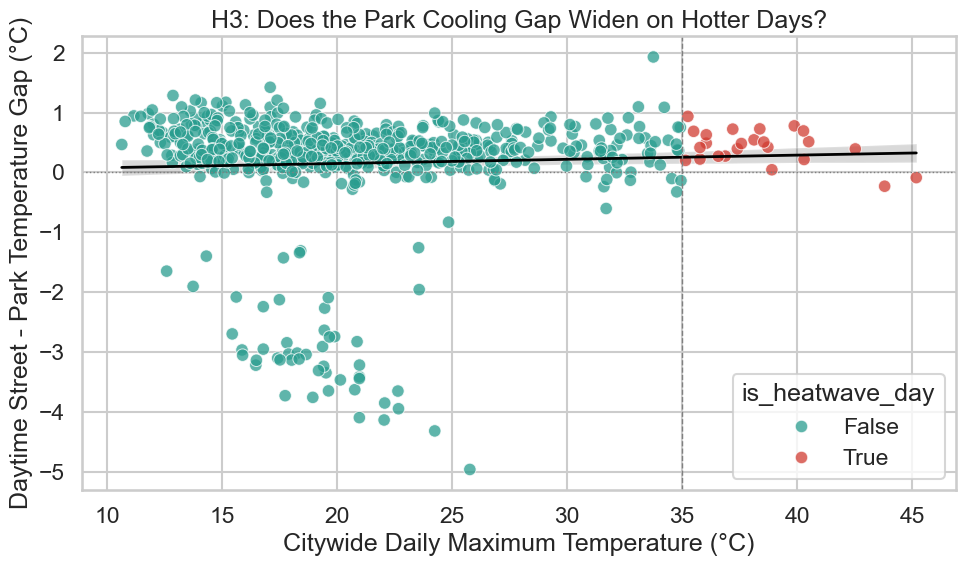

/var/folders/qp/5zn1806d2q183t3j1x_pt5x80000gn/T/ipykernel_20989/1296554071.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


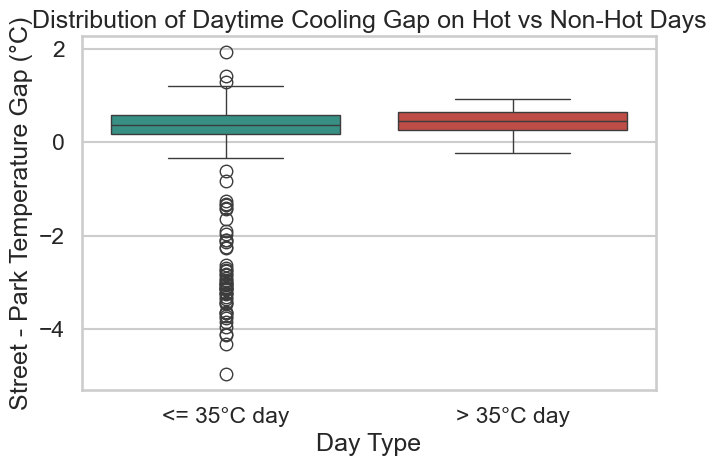

,count,mean,std,min,25%,50%,75%,max
day_type,,,,,,,,
<= 35°C day,597.0,0.149706,1.007340,-4.961500,0.174000,0.369792,0.598750,1.930417
> 35°C day,24.0,0.428260,0.280175,-0.229583,0.259427,0.453592,0.644472,0.937917


In [31]:
# Citywide daily max from all hourly site observations.
daily_city_max = (
    hourly_site.assign(date=hourly_site['Time'].dt.date)
    .groupby('date', as_index=False)['AirTemperature']
    .max()
    .rename(columns={'AirTemperature': 'citywide_daily_max_c'})
)

# Park-street daytime gap (13:00-17:00) per day.
daily_gap = (
    gap_df[gap_df['hour'].between(13, 17)]
    .groupby('date', as_index=False)['street_minus_park_temp_c']
    .mean()
    .rename(columns={'street_minus_park_temp_c': 'daytime_street_minus_park_c'})
)

h3 = daily_gap.merge(daily_city_max, on='date', how='inner')
h3['is_heatwave_day'] = h3['citywide_daily_max_c'] > 35
h3['day_type'] = np.where(h3['is_heatwave_day'], '> 35°C day', '<= 35°C day')

plt.figure(figsize=(10, 6))
sns.regplot(
    data=h3,
    x='citywide_daily_max_c',
    y='daytime_street_minus_park_c',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2},
)
sns.scatterplot(
    data=h3,
    x='citywide_daily_max_c',
    y='daytime_street_minus_park_c',
    hue='is_heatwave_day',
    palette={True: '#D13C32', False: '#2A9D8F'},
    alpha=0.75,
)
plt.axvline(35, linestyle='--', color='grey', linewidth=1)
plt.axhline(0, linestyle=':', color='grey', linewidth=1)
plt.title('H3: Does the Park Cooling Gap Widen on Hotter Days?')
plt.xlabel('Citywide Daily Maximum Temperature (°C)')
plt.ylabel('Daytime Street - Park Temperature Gap (°C)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=h3,
    x='day_type',
    y='daytime_street_minus_park_c',
    order=['<= 35°C day', '> 35°C day'],
    palette={'<= 35°C day': '#2A9D8F', '> 35°C day': '#D13C32'},
)
plt.title('Distribution of Daytime Cooling Gap on Hot vs Non-Hot Days')
plt.xlabel('Day Type')
plt.ylabel('Street - Park Temperature Gap (°C)')
plt.tight_layout()
plt.show()

h3.groupby('day_type')['daytime_street_minus_park_c'].describe()


## 8. H4 - Diurnal Asymmetry (Day vs Night Cooling)

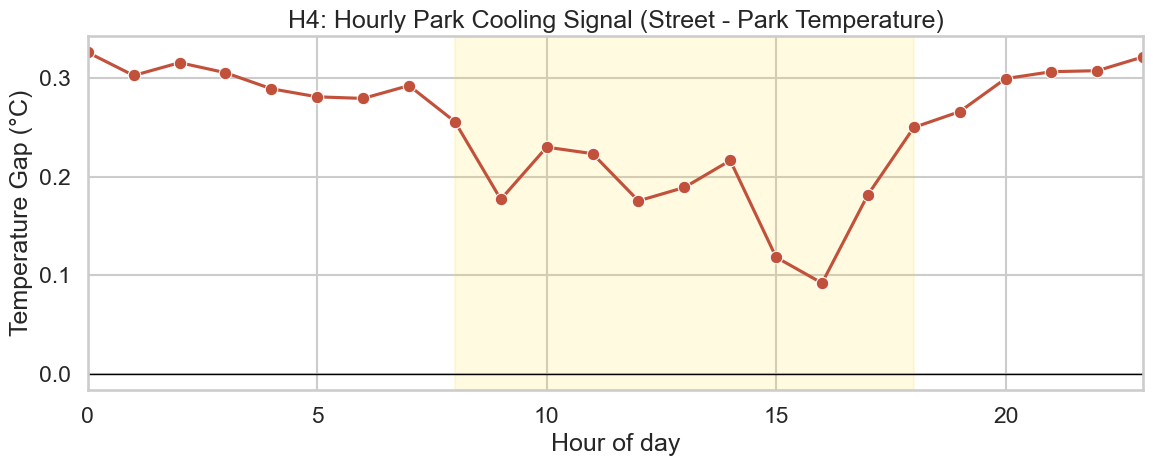

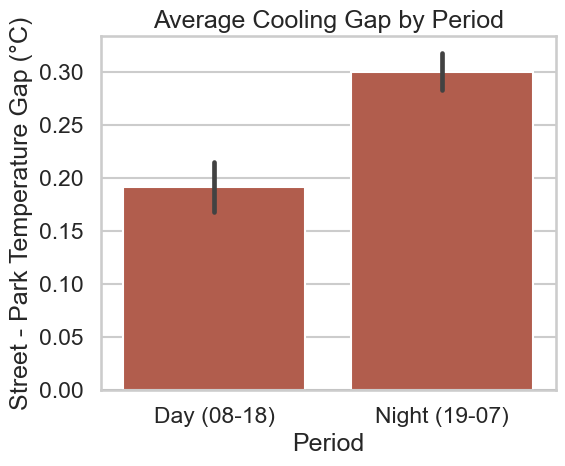

,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
Day (08-18),6825.0,0.191866,0.990768,-5.36875,0.0750,0.379167,0.675,3.212500
Night (19-07),8067.0,0.299562,0.777692,-6.66250,0.0375,0.341875,0.675,3.179167


In [32]:
hourly_gap = (
    gap_df.groupby('hour', as_index=False)['street_minus_park_temp_c']
    .mean()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_gap, x='hour', y='street_minus_park_temp_c', marker='o', color='#C2513C')
plt.axhline(0, color='black', linewidth=1)
plt.axvspan(8, 18, color='gold', alpha=0.12)
plt.title('H4: Hourly Park Cooling Signal (Street - Park Temperature)')
plt.xlabel('Hour of day')
plt.ylabel('Temperature Gap (°C)')
plt.xlim(0, 23)
plt.tight_layout()
plt.show()

gap_daynight = gap_df.copy()
gap_daynight['period'] = np.where(gap_daynight['hour'].between(8, 18), 'Day (08-18)', 'Night (19-07)')

plt.figure(figsize=(6, 5))
sns.barplot(data=gap_daynight, x='period', y='street_minus_park_temp_c', color='#C2513C')
plt.axhline(0, color='black', linewidth=1)
plt.title('Average Cooling Gap by Period')
plt.xlabel('Period')
plt.ylabel('Street - Park Temperature Gap (°C)')
plt.tight_layout()
plt.show()

gap_daynight.groupby('period')['street_minus_park_temp_c'].describe()


## 8B. Wind Speed Impact on Temperature by Site Class (Summer)

Does wind cool parks, streets, and rooftops the same way? This plot focuses on
**summer afternoons (Nov-Mar, 12:00-18:00)** and shows mean `AirTemperature` per
wind-speed bin for each site class, with 95% CI shading.

In [ ]:
LAND_PALETTE = {'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'}
LAND_ORDER = ['park', 'street', 'rooftop']

wind_df = working.dropna(subset=['AverageWindSpeed', 'AirTemperature']).copy()
wind_df = wind_df[
    (wind_df['AverageWindSpeed'] >= 0)
    & (wind_df['AverageWindSpeed'] < 20)
    & wind_df['LandType'].isin(LAND_ORDER)
]
wind_df['hour'] = wind_df['Time'].dt.hour
wind_df['month'] = wind_df['Time'].dt.month

summer_wind = wind_df[
    wind_df['month'].isin(SUMMER_MONTHS) & wind_df['hour'].between(12, 18)
].copy()

WIND_BINS = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 12]
bin_labels = [f'{lo:g}-{hi:g}' for lo, hi in zip(WIND_BINS[:-1], WIND_BINS[1:])]
summer_wind['wind_bin'] = pd.cut(
    summer_wind['AverageWindSpeed'], bins=WIND_BINS, labels=bin_labels, include_lowest=True,
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=summer_wind, x='wind_bin', y='AirTemperature',
    hue='LandType', hue_order=LAND_ORDER, palette=LAND_PALETTE,
    marker='o', errorbar=('ci', 95), ax=ax,
)
ax.set_title('Wind Speed vs Air Temperature by Site Class — Summer Afternoons (Nov-Mar, 12-18)')
ax.set_xlabel('Average Wind Speed bin (m/s)')
ax.set_ylabel('Air Temperature (°C)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Site class')

plt.tight_layout()
plt.show()

# Per-class Pearson correlation and OLS slope (°C per +1 m/s).
rows = []
for land in LAND_ORDER:
    subset = summer_wind[summer_wind['LandType'] == land]
    x = subset['AverageWindSpeed'].to_numpy()
    y = subset['AirTemperature'].to_numpy()
    rows.append({
        'LandType': land,
        'n': len(subset),
        'corr': np.corrcoef(x, y)[0, 1],
        'slope_c_per_mps': np.polyfit(x, y, 1)[0],
    })

wind_temp_summary = pd.DataFrame(rows).round(3)
wind_temp_summary

## 9. H5/H6 Optional: Canopy Dose-Response and Species/Size Effects

To activate these plots, place a file named `sensor_ecology_context.csv` in this folder with at least:
- `SensorLocation`
- `canopy_100m_pct`
- `canopy_250m_pct`

Optional columns for H6:
- `large_crown_trees`
- `mature_trees`
- `mean_crown_diameter_m`


In [33]:
# Sensor-level daytime baseline temperature (target for canopy/species links).
sensor_daytime_temp = (
    hourly_site[hourly_site['Time'].dt.hour.between(13, 17)]
    .groupby(['SensorLocation', 'SiteShortName', 'LandType'], as_index=False)['AirTemperature']
    .mean()
    .rename(columns={'AirTemperature': 'mean_daytime_temp_c'})
)

eco_path = Path('sensor_ecology_context.csv')
if not eco_path.exists():
    print('sensor_ecology_context.csv not found. Add it to enable H5/H6 plots.')
else:
    eco = pd.read_csv(eco_path)

    required = {'SensorLocation', 'canopy_100m_pct', 'canopy_250m_pct'}
    missing = sorted(required - set(eco.columns))

    if missing:
        print(f"Missing required columns for H5: {missing}")
    else:
        h56 = sensor_daytime_temp.merge(eco, on='SensorLocation', how='inner')

        # H5: canopy dose-response.
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

        sns.regplot(
            data=h56,
            x='canopy_100m_pct',
            y='mean_daytime_temp_c',
            ax=axes[0],
            scatter_kws={'s': 90, 'alpha': 0.9},
            line_kws={'color': 'black', 'linewidth': 2},
        )
        axes[0].set_title('H5: Daytime Temp vs Canopy Cover (100m)')
        axes[0].set_xlabel('Canopy Cover within 100m (%)')
        axes[0].set_ylabel('Mean Daytime Temperature (°C)')

        sns.regplot(
            data=h56,
            x='canopy_250m_pct',
            y='mean_daytime_temp_c',
            ax=axes[1],
            scatter_kws={'s': 90, 'alpha': 0.9},
            line_kws={'color': 'black', 'linewidth': 2},
        )
        axes[1].set_title('H5: Daytime Temp vs Canopy Cover (250m)')
        axes[1].set_xlabel('Canopy Cover within 250m (%)')

        plt.tight_layout()
        plt.show()

        if h56['canopy_250m_pct'].nunique() > 1:
            slope_250 = np.polyfit(h56['canopy_250m_pct'], h56['mean_daytime_temp_c'], 1)[0]
            print(f"Estimated slope (250m): {slope_250:.3f} °C per +1% canopy")
            print(f"Headline effect: {slope_250 * 10:.2f} °C per +10% canopy")

        # H6: species/size context (if available).
        has_large = 'large_crown_trees' in h56.columns
        has_mature = 'mature_trees' in h56.columns

        if has_large or has_mature:
            x_col = 'large_crown_trees' if has_large else 'mature_trees'
            hue_col = 'LandType'
            size_col = 'mean_crown_diameter_m' if 'mean_crown_diameter_m' in h56.columns else None

            plt.figure(figsize=(9, 6))
            sns.scatterplot(
                data=h56,
                x=x_col,
                y='mean_daytime_temp_c',
                hue=hue_col,
                size=size_col,
                sizes=(60, 260) if size_col else None,
                palette={'park': '#2E8B57', 'street': '#C2513C', 'rooftop': '#3B6FB6'},
            )
            sns.regplot(data=h56, x=x_col, y='mean_daytime_temp_c', scatter=False, color='black', line_kws={'linewidth': 2})
            plt.title('H6: Tree Size/Maturity Context vs Daytime Cooling')
            plt.xlabel(x_col.replace('_', ' ').title())
            plt.ylabel('Mean Daytime Temperature (°C)')
            plt.tight_layout()
            plt.show()
        else:
            print('No H6 size/species columns found (expected one of: large_crown_trees, mature_trees).')

        h56


sensor_ecology_context.csv not found. Add it to enable H5/H6 plots.


## 10. Quick Interpretation Prompts

Use these visual diagnostics to answer your expanded hypothesis:
- `H1`: Is `street_minus_park_gap_c` consistently positive, especially in summer afternoons?
- `H2`: Is `park_minus_street_rh_pct` mostly positive at matched hours?
- `H3`: Does the slope in the hot-day scatter trend upward as city max temperature increases?
- `H4`: Is daytime cooling gap larger than nighttime gap?
- `H5/H6`: After adding canopy/tree context, do higher canopy and larger/more mature trees align with lower daytime temperature?
